
Обработка тикера SBER ...


[I 2025-03-17 15:04:47,321] A new study created in memory with name: no-name-c75b42a5-8945-4444-938c-0665da0091b7


Число строк после очистки для SBER: 2993
X_train: (1775, 20, 11), y_train: (1775, 1)
X_val:   (579, 20, 11), y_val:   (579, 1)
X_test:  (579, 20, 11), y_test:  (579, 1)


[I 2025-03-17 15:05:19,767] Trial 0 finished with value: 0.003076569875702262 and parameters: {'lstm_units': 256, 'gru_units': 80, 'dense_units': 32, 'dropout_rate': 0.2, 'learning_rate': 0.00460845947652612}. Best is trial 0 with value: 0.003076569875702262.
[I 2025-03-17 15:05:35,062] Trial 1 finished with value: 0.005119068548083305 and parameters: {'lstm_units': 64, 'gru_units': 128, 'dense_units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.0036318185549646755}. Best is trial 0 with value: 0.003076569875702262.
[I 2025-03-17 15:05:47,699] Trial 2 finished with value: 0.005904024932533503 and parameters: {'lstm_units': 96, 'gru_units': 96, 'dense_units': 80, 'dropout_rate': 0.3, 'learning_rate': 0.0030925372853252576}. Best is trial 0 with value: 0.003076569875702262.
[I 2025-03-17 15:06:25,559] Trial 3 finished with value: 0.002565666800364852 and parameters: {'lstm_units': 128, 'gru_units': 48, 'dense_units': 64, 'dropout_rate': 0.25, 'learning_rate': 0.008370875894542135}. Best 

Лучшие гиперпараметры для SBER: {'lstm_units': 224, 'gru_units': 32, 'dense_units': 128, 'dropout_rate': 0.1, 'learning_rate': 0.0008680617768672247}
Epoch 1/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0389 - val_loss: 0.0059 - learning_rate: 8.6806e-04
Epoch 2/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0044 - val_loss: 0.0049 - learning_rate: 8.6806e-04
Epoch 3/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0031 - val_loss: 0.0034 - learning_rate: 8.6806e-04
Epoch 4/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0029 - val_loss: 0.0041 - learning_rate: 8.6806e-04
Epoch 5/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0026 - val_loss: 0.0072 - learning_rate: 8.6806e-04
Epoch 6/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0024 - val_loss: 0.0045 - learning_rate: 8.6806e-04
Epoch 7/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0021 - val_loss: 0.0040 - learning_rate: 8.6806e-04
Epoch 8/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 18

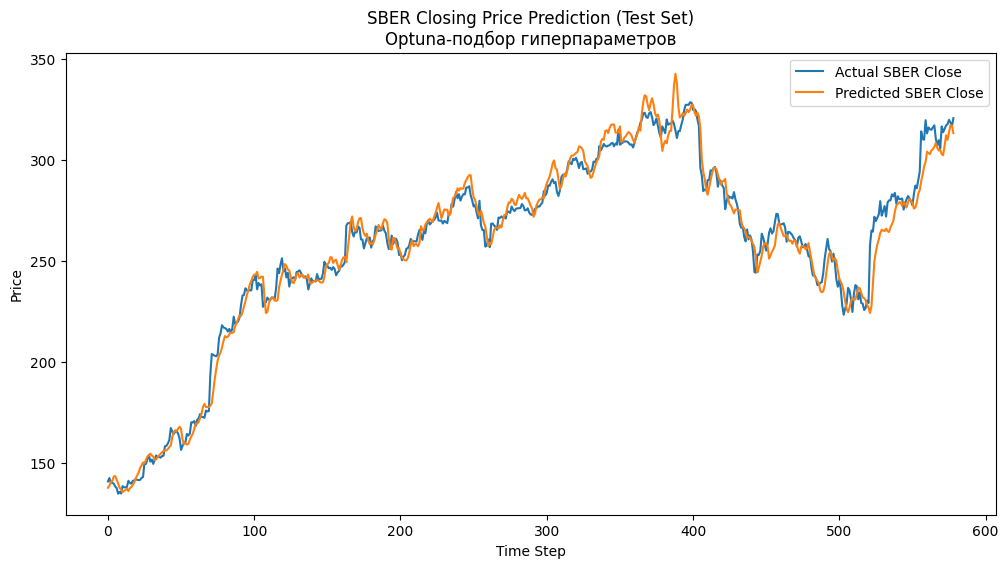

In [7]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error
import optuna

# ============================================================
# Функция для загрузки данных с MOEX
# ============================================================
def fetch_moex_eod_data(security, engine, market, board, start_date, end_date):
    base_url = f"https://iss.moex.com/iss/history/engines/{engine}/markets/{market}/boards/{board}/securities/{security}.json"
    all_data = []
    columns = None
    offset = 0
    limit = 100
    while True:
        params = {"from": start_date, "till": end_date, "start": offset}
        response = requests.get(base_url, params=params)
        if response.status_code != 200:
            print(f"Ошибка: HTTP {response.status_code}")
            break
        data = response.json()
        try:
            if columns is None:
                columns = data["history"]["columns"]
            page_data = data["history"]["data"]
            if not page_data:
                break
            all_data.extend(page_data)
            if len(page_data) < limit:
                break
            offset += limit
        except KeyError:
            print("Ошибка формата данных.")
            break
    if all_data and columns:
        return pd.DataFrame(all_data, columns=columns)
    else:
        return None

# ============================================================
# Функция для расчёта RSI
# ============================================================
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / (loss + 1e-10)
    rsi = 100 - (100 / (1 + rs))
    return rsi

# ============================================================
# Кастомный слой внимания (Attention)
# ============================================================
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def build(self, input_shape):
        hidden_dim = input_shape[-1]
        self.W = self.add_weight(name='att_weight', shape=(hidden_dim, 1), initializer='glorot_uniform')
        self.b = self.add_weight(name='att_bias', shape=(input_shape[1], 1), initializer='zeros')
        super().build(input_shape)
    def call(self, inputs):
        e = tf.tensordot(inputs, self.W, axes=[[2],[0]]) + self.b
        e = tf.squeeze(e, axis=-1)
        alpha = tf.nn.softmax(e)
        alpha = tf.expand_dims(alpha, axis=-1)
        context = inputs * alpha
        context = tf.reduce_sum(context, axis=1)
        return context

# ============================================================
# Функция для создания последовательностей
# ============================================================
def create_sequences(X, y, seq_length=20):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

# ============================================================
# Основной пайплайн с Optuna для одного тикера
# ============================================================
def run_optuna_for_ticker(ticker, start_date, end_date, n_trials=30):
    print(f"\nОбработка тикера {ticker} ...")
    # Загрузка данных для тикера
    df = fetch_moex_eod_data(ticker, "stock", "shares", "TQBR", start_date, end_date)
    if df is None:
        print(f"Ошибка загрузки данных для {ticker}")
        return
    df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"])
    df.sort_values("TRADEDATE", inplace=True)
    
    # Переименование столбцов для тикера
    close_col = f"CLOSE_{ticker}"
    open_col  = f"OPEN_{ticker}"
    high_col  = f"HIGH_{ticker}"
    low_col   = f"LOW_{ticker}"
    vol_col   = f"VOL_{ticker}"
    df.rename(columns={"CLOSE": close_col, "OPEN": open_col, "HIGH": high_col, "LOW": low_col, "VOLUME": vol_col}, inplace=True)
    df = df[["TRADEDATE", open_col, high_col, low_col, close_col, vol_col]]
    
    # Загрузка дополнительных данных (IMOEX и USD/RUB)
    imoex_df = fetch_moex_eod_data("IMOEX", "stock", "index", "SNDX", start_date, end_date)
    usd_df   = fetch_moex_eod_data("USD000UTSTOM", "currency", "selt", "CETS", start_date, end_date)
    if imoex_df is None or usd_df is None:
        print("Ошибка загрузки дополнительных датасетов.")
        return
    for d in [imoex_df, usd_df]:
        d["TRADEDATE"] = pd.to_datetime(d["TRADEDATE"])
        d.sort_values("TRADEDATE", inplace=True)
    imoex_df.rename(columns={"CLOSE": "CLOSE_IMOEX"}, inplace=True)
    usd_df.rename(columns={"CLOSE": "CLOSE_USD"}, inplace=True)
    imoex_df = imoex_df[["TRADEDATE", "CLOSE_IMOEX"]]
    usd_df   = usd_df[["TRADEDATE", "CLOSE_USD"]]
    
    merged_df = df.merge(imoex_df, on="TRADEDATE", how="outer")\
                  .merge(usd_df, on="TRADEDATE", how="outer")
    merged_df.sort_values("TRADEDATE", inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    merged_df.dropna(subset=[close_col, "CLOSE_IMOEX", "CLOSE_USD"], inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    
    # Вычисляем RSI
    rsi_col = f"RSI_{ticker}"
    merged_df[rsi_col] = compute_rsi(merged_df[close_col], period=14)
    merged_df.dropna(subset=[rsi_col], inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    
    # Добавляем свечные признаки
    body_col = f"BODY_{ticker}"
    upper_shadow_col = f"UPPER_SHADOW_{ticker}"
    lower_shadow_col = f"LOWER_SHADOW_{ticker}"
    merged_df[body_col] = (merged_df[close_col] - merged_df[open_col]).abs()
    merged_df[upper_shadow_col] = merged_df[high_col] - merged_df[[open_col, close_col]].max(axis=1)
    merged_df[lower_shadow_col] = merged_df[[open_col, close_col]].min(axis=1) - merged_df[low_col]
    
    print(f"Число строк после очистки для {ticker}: {len(merged_df)}")
    
    # Формирование признаков
    features = [open_col, high_col, low_col, close_col, vol_col, "CLOSE_IMOEX", "CLOSE_USD", rsi_col, body_col, upper_shadow_col, lower_shadow_col]
    target_cols = [close_col]
    data = merged_df[features].values.astype(float)
    targets = merged_df[target_cols].values.astype(float)
    
    # Разбиваем данные: 60% - train, 20% - val, 20% - test
    total_len = len(data)
    train_end = int(0.6 * total_len)
    val_end = int(0.8 * total_len)
    train_data = data[:train_end]
    train_targets = targets[:train_end]
    val_data = data[train_end:val_end]
    val_targets = targets[train_end:val_end]
    test_data = data[val_end:]
    test_targets = targets[val_end:]
    
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    scaler_X.fit(train_data)
    scaler_y.fit(train_targets)
    train_data_scaled = scaler_X.transform(train_data)
    val_data_scaled = scaler_X.transform(val_data)
    test_data_scaled = scaler_X.transform(test_data)
    train_targets_scaled = scaler_y.transform(train_targets)
    val_targets_scaled = scaler_y.transform(val_targets)
    test_targets_scaled = scaler_y.transform(test_targets)
    
    seq_length = 20
    X_train, y_train = create_sequences(train_data_scaled, train_targets_scaled, seq_length)
    X_val, y_val = create_sequences(val_data_scaled, val_targets_scaled, seq_length)
    X_test, y_test = create_sequences(test_data_scaled, test_targets_scaled, seq_length)
    
    print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
    print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")
    
    # Определяем objective для Optuna
    def objective(trial):
        lstm_units = trial.suggest_int("lstm_units", 64, 256, step=32)
        gru_units = trial.suggest_int("gru_units", 32, 128, step=16)
        dense_units = trial.suggest_int("dense_units", 32, 128, step=16)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.3, step=0.05)
        learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
        
        inp = Input(shape=(seq_length, len(features)))
        x = LSTM(lstm_units, return_sequences=True)(inp)
        x = Dropout(dropout_rate)(x)
        x = GRU(gru_units, return_sequences=True)(x)
        x = Dropout(dropout_rate)(x)
        x = AttentionLayer()(x)
        x = Dense(dense_units, activation="relu")(x)
        x = Dropout(dropout_rate)(x)
        out = Dense(1)(x)
        model = Model(inputs=inp, outputs=out)
        optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)
        model.compile(optimizer=optimizer, loss="mse")
        
        cb = [EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
        history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                            epochs=50, batch_size=16, callbacks=cb, verbose=0)
        return min(history.history["val_loss"])
    
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)
    print(f"Лучшие гиперпараметры для {ticker}: {study.best_params}")
    
    # Обучаем финальную модель на объединённых train+val данных с лучшими параметрами
    X_train_val = np.concatenate((X_train, X_val), axis=0)
    y_train_val = np.concatenate((y_train, y_val), axis=0)
    
    best_params = study.best_params
    inp = Input(shape=(seq_length, len(features)))
    x = LSTM(best_params["lstm_units"], return_sequences=True)(inp)
    x = Dropout(best_params["dropout_rate"])(x)
    x = GRU(best_params["gru_units"], return_sequences=True)(x)
    x = Dropout(best_params["dropout_rate"])(x)
    x = AttentionLayer()(x)
    x = Dense(best_params["dense_units"], activation="relu")(x)
    x = Dropout(best_params["dropout_rate"])(x)
    out = Dense(1)(x)
    final_model = Model(inputs=inp, outputs=out)
    optimizer = tf.keras.optimizers.Nadam(learning_rate=best_params["learning_rate"])
    final_model.compile(optimizer=optimizer, loss="mse")
    
    cb_final = [
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)
    ]
    final_history = final_model.fit(X_train_val, y_train_val, validation_data=(X_test, y_test),
                                     epochs=50, batch_size=16, callbacks=cb_final, verbose=1)
    
    test_loss = final_model.evaluate(X_test, y_test, verbose=1)
    print(f"Test Loss (MSE) для {ticker}: {test_loss}")
    
    preds_scaled = final_model.predict(X_test)
    preds = scaler_y.inverse_transform(preds_scaled)
    actuals = scaler_y.inverse_transform(y_test)
    
    mse_orig = mean_squared_error(actuals, preds)
    rmse_orig = np.sqrt(mse_orig)
    mae_orig = np.mean(np.abs(actuals - preds))
    mape_orig = np.mean(np.abs((actuals - preds) / actuals)) * 100
    
    print(f"Метрики для {ticker}:")
    print(f"MSE (рубли^2): {mse_orig:.3f}")
    print(f"RMSE (рубли):  {rmse_orig:.3f}")
    print(f"MAE (рубли):   {mae_orig:.3f}")
    print(f"MAPE:          {mape_orig:.2f}%")
    
    plt.figure(figsize=(12, 6))
    plt.plot(actuals, label=f"Actual {ticker} Close")
    plt.plot(preds, label=f"Predicted {ticker} Close")
    plt.title(f"{ticker} Closing Price Prediction (Test Set)\nOptuna-подбор гиперпараметров")
    plt.xlabel("Time Step")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

# ============================================================
# Запуск для пары тикеров (например, GAZP и LKOH)
# ============================================================
start_date = "2010-01-01"
end_date = datetime.today().strftime("%Y-%m-%d")
tickers = ["SBER"]

for ticker in tickers:
    run_optuna_for_ticker(ticker, start_date, end_date, n_trials=30)


In [2]:
import os
import pickle
import requests
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ================================================
# 1. Функции для загрузки данных и предобработки
# ================================================
def fetch_moex_eod_data(security, engine, market, board, start_date, end_date):
    base_url = f"https://iss.moex.com/iss/history/engines/{engine}/markets/{market}/boards/{board}/securities/{security}.json"
    all_data = []
    columns = None
    offset = 0
    limit = 100
    while True:
        params = {"from": start_date, "till": end_date, "start": offset}
        response = requests.get(base_url, params=params)
        if response.status_code != 200:
            print(f"Ошибка: HTTP {response.status_code}")
            break
        data = response.json()
        try:
            if columns is None:
                columns = data["history"]["columns"]
            page_data = data["history"]["data"]
            if not page_data:
                break
            all_data.extend(page_data)
            if len(page_data) < limit:
                break
            offset += limit
        except KeyError:
            print("Ошибка формата данных.")
            break
    if all_data and columns:
        return pd.DataFrame(all_data, columns=columns)
    else:
        return None

def compute_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / (loss + 1e-10)
    rsi = 100 - (100 / (1 + rs))
    return rsi

def preprocess_data(df, ticker):
    df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"])
    df.sort_values("TRADEDATE", inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    close_col = f"CLOSE_{ticker}"
    open_col  = f"OPEN_{ticker}"
    high_col  = f"HIGH_{ticker}"
    low_col   = f"LOW_{ticker}"
    vol_col   = f"VOL_{ticker}"
    df.rename(columns={
        "CLOSE": close_col,
        "OPEN": open_col,
        "HIGH": high_col,
        "LOW": low_col,
        "VOLUME": vol_col
    }, inplace=True)
    
    rsi_col = f"RSI_{ticker}"
    df[rsi_col] = compute_rsi(df[close_col], period=14)
    df.dropna(subset=[rsi_col], inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    # Дополнительные свечные признаки (опционально)
    body_col = f"BODY_{ticker}"
    upper_shadow_col = f"UPPER_SHADOW_{ticker}"
    lower_shadow_col = f"LOWER_SHADOW_{ticker}"
    df[body_col] = (df[close_col] - df[open_col]).abs()
    df[upper_shadow_col] = df[high_col] - df[[open_col, close_col]].max(axis=1)
    df[lower_shadow_col] = df[[open_col, close_col]].min(axis=1) - df[low_col]
    
    return df

def create_sequences(X, y, seq_length=20):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

# ================================================
# 2. Определение модели (TensorFlow)
# ================================================
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
    
    def build(self, input_shape):
        hidden_dim = input_shape[-1]
        self.W = self.add_weight(
            name='att_weight',
            shape=(hidden_dim, 1),
            initializer='glorot_uniform'
        )
        self.b = self.add_weight(
            name='att_bias',
            shape=(input_shape[1], 1),
            initializer='zeros'
        )
        super(AttentionLayer, self).build(input_shape)
    
    def call(self, inputs):
        e = tf.tensordot(inputs, self.W, axes=[[2],[0]]) + self.b
        e = tf.squeeze(e, axis=-1)
        alpha = tf.nn.softmax(e)
        alpha = tf.expand_dims(alpha, axis=-1)
        context = inputs * alpha
        context = tf.reduce_sum(context, axis=1)
        return context

def build_model(seq_length, num_features, lstm_units, gru_units, dense_units, dropout_rate, learning_rate):
    inp = Input(shape=(seq_length, num_features))
    x = LSTM(lstm_units, return_sequences=True)(inp)
    x = Dropout(dropout_rate)(x)
    x = GRU(gru_units, return_sequences=True)(x)
    x = Dropout(dropout_rate)(x)
    x = AttentionLayer()(x)
    x = Dense(dense_units, activation="relu")(x)
    x = Dropout(dropout_rate)(x)
    out = Dense(1)(x)
    
    model = Model(inputs=inp, outputs=out)
    optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss="mse")
    return model

# ================================================
# 3. Скрипт для обучения и сохранения модели для нескольких тикеров
# ================================================
if __name__ == "__main__":
    # Список тикеров, для которых будем обучать модели
    tickers = ["SBER", "GAZP", "LKOH"]  # можно расширить
    start_date = "2013-01-01"
    end_date = datetime.today().strftime("%Y-%m-%d")
    
    # Загружаем общие данные (IMOEX и USD/RUB) один раз, т.к. они общие для всех тикеров
    print("Загружаем IMOEX...")
    imoex_df = fetch_moex_eod_data("IMOEX", "stock", "index", "SNDX", start_date, end_date)
    print("Загружаем USD/RUB (USD000UTSTOM)...")
    usd_df = fetch_moex_eod_data("USD000UTSTOM", "currency", "selt", "CETS", start_date, end_date)
    if imoex_df is None or usd_df is None:
        raise ValueError("Ошибка при загрузке дополнительных датасетов.")
    
    # Приводим общие данные к нужному формату
    for df in [imoex_df, usd_df]:
        df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"])
        df.sort_values("TRADEDATE", inplace=True)
        df.reset_index(drop=True, inplace=True)
    imoex_df.rename(columns={"CLOSE": "CLOSE_IMOEX"}, inplace=True)
    usd_df.rename(columns={"CLOSE": "CLOSE_USD"}, inplace=True)
    imoex_df = imoex_df[["TRADEDATE", "CLOSE_IMOEX"]]
    usd_df = usd_df[["TRADEDATE", "CLOSE_USD"]]
    
    # Папка для сохранения моделей
    os.makedirs("models", exist_ok=True)
    
    # Гиперпараметры модели (вы можете настроить их по своему усмотрению)
    lstm_units = 160
    gru_units = 32
    dense_units = 128
    dropout_rate = 0.1
    learning_rate = 0.001
    seq_length = 20
    
    for ticker in tickers:
        print(f"\n=== Обучение модели для {ticker} ===")
        # Загрузка данных для тикера
        print(f"Загружаем {ticker}...")
        ticker_df = fetch_moex_eod_data(ticker, "stock", "shares", "TQBR", start_date, end_date)
        if ticker_df is None or ticker_df.empty:
            print(f"Ошибка загрузки данных для {ticker}")
            continue
        
        # Предобработка данных для тикера
        ticker_df = preprocess_data(ticker_df, ticker)
        
        # Объединяем с общими данными по дате
        merged_df = ticker_df.merge(imoex_df, on="TRADEDATE", how="outer") \
                              .merge(usd_df, on="TRADEDATE", how="outer")
        merged_df.sort_values("TRADEDATE", inplace=True)
        merged_df.reset_index(drop=True, inplace=True)
        merged_df.dropna(subset=[f"CLOSE_{ticker}", "CLOSE_IMOEX", "CLOSE_USD"], inplace=True)
        merged_df.reset_index(drop=True, inplace=True)
        
        # Если RSI еще не добавлен, добавляем
        if f"RSI_{ticker}" not in merged_df.columns:
            merged_df[f"RSI_{ticker}"] = compute_rsi(merged_df[f"CLOSE_{ticker}"], period=14)
            merged_df.dropna(subset=[f"RSI_{ticker}"], inplace=True)
            merged_df.reset_index(drop=True, inplace=True)
        
        print(f"Число строк после очистки для {ticker}: {len(merged_df)}")
        
        # Формирование признаков и целевой переменной
        features = [f"OPEN_{ticker}", f"HIGH_{ticker}", f"LOW_{ticker}", f"CLOSE_{ticker}", f"VOL_{ticker}",
                    "CLOSE_IMOEX", "CLOSE_USD", f"RSI_{ticker}"]
        target_col = f"CLOSE_{ticker}"
        
        data = merged_df[features].values.astype(float)
        targets = merged_df[[target_col]].values.astype(float)
        
        # Разбивка на train/test (60% train, 40% test)
        total_len = len(data)
        train_end = int(0.6 * total_len)
        train_data = data[:train_end]
        test_data  = data[train_end:]
        train_targets = targets[:train_end]
        test_targets  = targets[train_end:]
        
        # Масштабирование данных
        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()
        scaler_X.fit(train_data)
        scaler_y.fit(train_targets)
        train_data_scaled = scaler_X.transform(train_data)
        test_data_scaled  = scaler_X.transform(test_data)
        train_targets_scaled = scaler_y.transform(train_targets)
        test_targets_scaled  = scaler_y.transform(test_targets)
        
        # Формирование скользящих окон
        X_train, y_train = create_sequences(train_data_scaled, train_targets_scaled, seq_length)
        X_test, y_test = create_sequences(test_data_scaled, test_targets_scaled, seq_length)
        print("X_train:", X_train.shape, "y_train:", y_train.shape)
        print("X_test:", X_test.shape, "y_test:", y_test.shape)
        
        # Обучение модели
        model = build_model(seq_length, len(features), lstm_units, gru_units, dense_units, dropout_rate, learning_rate)
        model.summary()
        
        early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
        history = model.fit(
            X_train, y_train,
            epochs=45,
            batch_size=32,
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=1
        )
        
        # Оценка модели
        test_loss = model.evaluate(X_test, y_test, verbose=1)
        print(f"Test Loss (MSE) для {ticker}: {test_loss}")
        
        preds_scaled = model.predict(X_test)
        preds = scaler_y.inverse_transform(preds_scaled)
        actuals = scaler_y.inverse_transform(y_test)
        
        mse_val = mean_squared_error(actuals, preds)
        rmse_val = np.sqrt(mse_val)
        mae_val = np.mean(np.abs(actuals - preds))
        mape_val = np.mean(np.abs((actuals - preds) / actuals)) * 100
        print(f"Метрики для {ticker}:")
        print(f"MSE (рубли^2): {mse_val:.3f}")
        print(f"RMSE (рубли):  {rmse_val:.3f}")
        print(f"MAE (рубли):   {mae_val:.3f}")
        print(f"MAPE:          {mape_val:.2f}%")
        
        # Сохраняем модель и скейлеры
        model_save_path = f"models/{ticker}_final_model.keras"
        scaler_X_path = f"models/{ticker}_scaler_X.pkl"
        scaler_y_path = f"models/{ticker}_scaler_y.pkl"
        model.save(model_save_path)
        with open(scaler_X_path, "wb") as f:
            pickle.dump(scaler_X, f)
        with open(scaler_y_path, "wb") as f:
            pickle.dump(scaler_y, f)

        
        # Можно сохранить график (опционально)
        plt.figure(figsize=(12, 6))
        plt.plot(actuals, label="Actual")
        plt.plot(preds, label="Predicted")
        plt.title(f"{ticker} Closing Price Prediction (Test Set)")
        plt.xlabel("Time Step")
        plt.ylabel("Price")
        plt.legend()
        plt.savefig(f"models/{ticker}_prediction.png")
        plt.close()

        print(f"Модель и скейлеры для {ticker} сохранены.\n")


Загружаем IMOEX...
Загружаем USD/RUB (USD000UTSTOM)...

=== Обучение модели для SBER ===
Загружаем SBER...
Число строк после очистки для SBER: 2995
X_train: (1777, 20, 8) y_train: (1777, 1)
X_test: (1178, 20, 8) y_test: (1178, 1)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 20, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 20, 160)        │       108,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 20, 160)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 20, 32)         │        18,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 20, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer_3               │ (None, 32)             │            52 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,189 (512.46 KB)

 Trainable params: 131,189 (512.46 KB)

...

 Total params: 131,189 (512.46 KB)

 Trainable params: 131,189 (512.46 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0146 - val_loss: 0.0100
Epoch 2/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0013 - val_loss: 0.0089
Epoch 3/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0013 - val_loss: 0.0085
Epoch 4/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0012 - val_loss: 0.0083
Epoch 5/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0010 - val_loss: 0.0079
Epoch 6/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0011 - val_loss: 0.0075
Epoch 7/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.8221e-04 - val_loss: 0.0072
Epoch 8/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9.9136e-04 - val_loss: 0.0081
Epoch 9/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.0710e-04 - val_loss: 0.0070
Epoch 10/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.1962e-04 - val_loss: 0.0068
Epoch 11/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.3805e-04 - val_loss: 0.0072
Epoch 12/40
100/100 ━

Метрики для LKOH:
MSE (рубли^2): 45875.881
RMSE (рубли):  214.187
MAE (рубли):   162.476
MAPE:          2.78%
Модель и скейлеры для LKOH сохранены.

